1.Imports Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import signal as scipy_signal
from scipy.fft import fft, fftfreq
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (GroupShuffleSplit, GroupKFold,
                                     cross_validate)
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             roc_curve, auc)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 12,
                     "axes.labelsize": 11, "figure.facecolor": "white"})

print("✓ All libraries imported successfully.")


✓ All libraries imported successfully.


 2.Data Loading & Data prepocessing

In [ ]:
# Load Excel dataset
EXCEL_PATH = "READINGS.xlsx"   # ← update path if needed

xl = pd.read_excel(EXCEL_PATH, sheet_name=None)

FS = 100.0          # Sampling frequency (Hz)
WINDOW_SIZE = 200   # 2-second windows (200 samples @ 100 Hz)
STEP_SIZE   = 100   # 50 % overlap

records = []
signal_id_counter = 0

for sheet_name, df_raw in xl.items():
    bpm = int(sheet_name.split()[0])
    freq_hz = bpm / 60.0

    # Skip header row; three paired (time, voltage) columns
    df_raw = df_raw.iloc[1:].reset_index(drop=True)
    df_raw.columns = ["t1","v1","t2","v2","t3","v3"]

    for set_idx, vcol in enumerate(["v1","v2","v3"], start=1):
        sig = pd.to_numeric(df_raw[vcol], errors="coerce").dropna().values.astype(np.float64)
        records.append({
            "bpm"       : bpm,
            "freq_hz"   : freq_hz,
            "set_idx"   : set_idx,
            "signal_id" : signal_id_counter,
            "signal"    : sig
        })
        signal_id_counter += 1

print(f"Loaded {len(records)} signals.")
for r in records:
    print(f"  BPM={r['bpm']:>4d}  set={r['set_idx']}  signal_id={r['signal_id']:>2d}  "          f"len={len(r['signal'])}  freq={r['freq_hz']:.2f} Hz")


Loaded 21 signals.
  BPM=  60  set=1  signal_id= 0  len=2001  freq=1.00 Hz
  BPM=  60  set=2  signal_id= 1  len=2001  freq=1.00 Hz
  BPM=  60  set=3  signal_id= 2  len=2001  freq=1.00 Hz
  BPM= 120  set=1  signal_id= 3  len=2001  freq=2.00 Hz
  BPM= 120  set=2  signal_id= 4  len=2001  freq=2.00 Hz
  BPM= 120  set=3  signal_id= 5  len=2001  freq=2.00 Hz
  BPM= 180  set=1  signal_id= 6  len=2001  freq=3.00 Hz
  BPM= 180  set=2  signal_id= 7  len=2001  freq=3.00 Hz
  BPM= 180  set=3  signal_id= 8  len=2001  freq=3.00 Hz
  BPM= 240  set=1  signal_id= 9  len=2001  freq=4.00 Hz
  BPM= 240  set=2  signal_id=10  len=2001  freq=4.00 Hz
  BPM= 240  set=3  signal_id=11  len=2001  freq=4.00 Hz
  BPM= 300  set=1  signal_id=12  len=2001  freq=5.00 Hz
  BPM= 300  set=2  signal_id=13  len=2001  freq=5.00 Hz
  BPM= 300  set=3  signal_id=14  len=2001  freq=5.00 Hz
  BPM= 360  set=1  signal_id=15  len=2001  freq=6.00 Hz
  BPM= 360  set=2  signal_id=16  len=2001  freq=6.00 Hz
  BPM= 360  set=3  signal_id=

3.Feature Extraction




In [ ]:
def extract_features(window: np.ndarray, fs: float = FS) -> dict:
    """Extract five domain features from a single signal window."""
    n     = len(window)
    # Temporal features
    mean  = np.mean(window)
    std   = np.std(window, ddof=1)
    energy= np.sum(window ** 2) / n       # normalised signal energy

    # ── Spectral features (via FFT)
    freqs = fftfreq(n, d=1.0 / fs)
    fft_vals = np.abs(fft(window))
    pos_mask = freqs > 0
    freqs_pos, fft_pos = freqs[pos_mask], fft_vals[pos_mask]

    dom_freq = freqs_pos[np.argmax(fft_pos)]          # dominant frequency

    # Welch PSD peak
    f_psd, psd = scipy_signal.welch(window, fs=fs, nperseg=min(n, 64))
    psd_peak   = np.max(psd)

    return {
        "mean"    : mean,
        "std"     : std,
        "energy"  : energy,
        "dom_freq": dom_freq,
        "psd_peak": psd_peak,
    }


# Slide windows across every signal
rows = []
for r in records:
    sig = r["signal"]
    starts = range(0, len(sig) - WINDOW_SIZE + 1, STEP_SIZE)
    for i, s in enumerate(starts):
        win   = sig[s : s + WINDOW_SIZE]
        feats = extract_features(win)
        feats["signal_id"]   = r["signal_id"]
        feats["bpm"]         = r["bpm"]
        feats["window_idx"]  = i
        rows.append(feats)

df = pd.DataFrame(rows)

# Binary label: Pathological (BPM >= 180) vs Non-Pathological
#    Clinical rationale: Parkinsonian rest tremor → 3–7 Hz (180–420 BPM equivalent)
df["label_binary"] = (df["bpm"] >= 180).astype(int)
df["label_name"]   = df["label_binary"].map({0:"Non-Pathological", 1:"Pathological"})

print(f"Feature matrix: {df.shape}")
print(f"\nClass distribution (binary):")
print(df["label_name"].value_counts())
print(f"\nSample features (first 5 rows):")
df[["bpm","signal_id","mean","std","energy","dom_freq","psd_peak","label_name"]].head()


Feature matrix: (399, 10)

Class distribution (binary):
label_name
Pathological        285
Non-Pathological    114
Name: count, dtype: int64

Sample features (first 5 rows):


,bpm,signal_id,mean,std,energy,dom_freq,psd_peak,label_name
0,60,0,2.415917,0.524998,6.110898,3.0,0.063655,Non-Pathological
1,60,0,2.436925,0.494999,6.182402,3.0,0.047289,Non-Pathological
2,60,0,2.329452,0.506669,5.681776,2.0,0.056221,Non-Pathological
3,60,0,2.169027,0.517933,4.971591,2.0,0.054538,Non-Pathological
4,60,0,2.097853,0.552847,4.705101,2.0,0.066612,Non-Pathological


4.FFT Analysis

BPM: 60 → Detected: 1.00 Hz
BPM: 120 → Detected: 2.00 Hz
BPM: 180 → Detected: 3.00 Hz
BPM: 240 → Detected: 4.00 Hz
BPM: 300 → Detected: 5.00 Hz
BPM: 360 → Detected: 6.00 Hz
BPM: 420 → Detected: 7.00 Hz


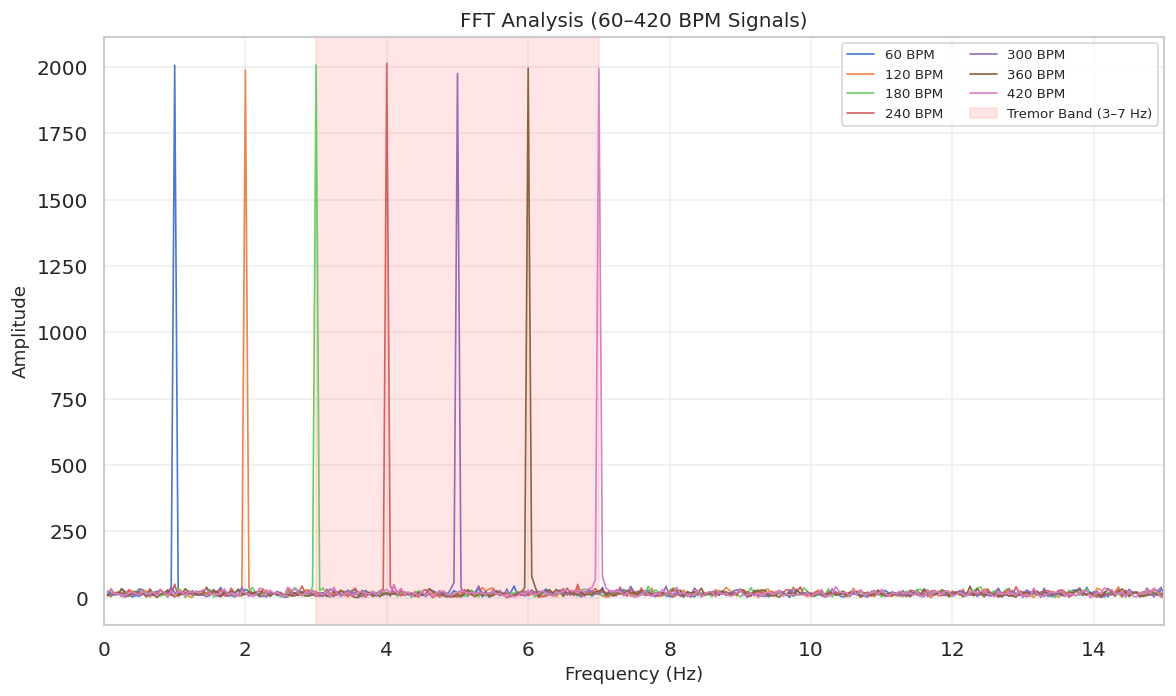

In [ ]:
# Sampling frequency

FS = 200  # Hz
duration = 20  # seconds

# Generate signals (60–420 BPM)

bpm_values = [60, 120, 180, 240, 300, 360, 420]
records = []

for bpm in bpm_values:
    freq = bpm / 60.0  # Hz
    t = np.linspace(0, duration, FS * duration)

    #  signal
    sig = np.sin(2*np.pi*freq*t)
    sig += 0.3 * np.random.randn(len(t))  # noise

    records.append({"bpm": bpm, "signal": sig})

# FFT function

def compute_fft(sig, FS):
    N = len(sig)
    fft_vals = fft(sig)
    freqs = fftfreq(N, 1/FS)

    mask = freqs > 0
    return freqs[mask], np.abs(fft_vals[mask])

# Plot all FFTs

plt.figure(figsize=(10, 6))

for r in records:
    freqs, fft_vals = compute_fft(r["signal"], FS)

    # peak detection
    peak_freq = freqs[np.argmax(fft_vals)]

    print(f"BPM: {r['bpm']} → Detected: {peak_freq:.2f} Hz")

    plt.plot(freqs, fft_vals, lw=1, label=f"{r['bpm']} BPM")

# Tremor band highlight
plt.axvspan(3, 7, color="red", alpha=0.1, label="Tremor Band (3–7 Hz)")

plt.xlim(0, 15)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("FFT Analysis (60–420 BPM Signals)")
plt.legend(ncol=2, fontsize=8)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

5. Heapmap and Features Analysis

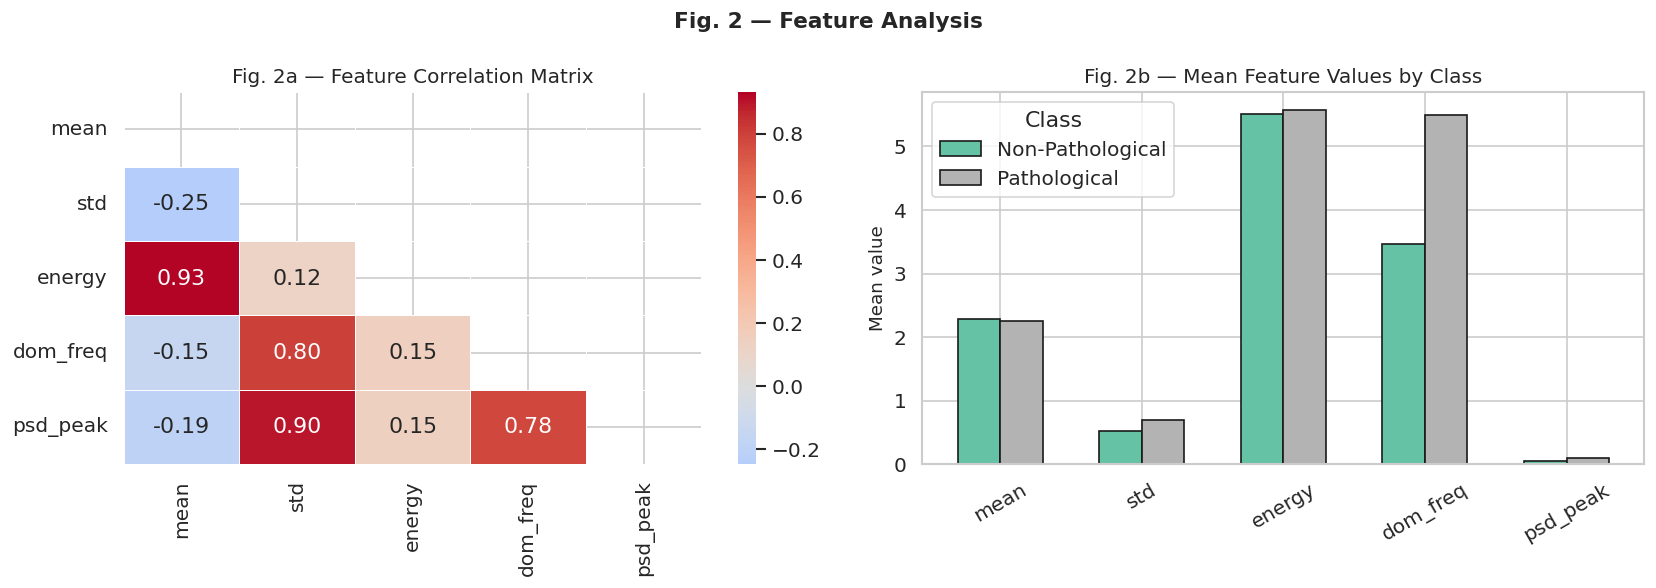

Fig. 2 saved.


In [ ]:
# Feature correlation heatmap
FEAT_COLS = ["mean","std","energy","dom_freq","psd_peak"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Correlation matrix
corr = df[FEAT_COLS].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, mask=mask, ax=axes[0], linewidths=0.5)
axes[0].set_title("Fig. 2a — Feature Correlation Matrix")

# Feature distributions by class
df_melt = df[FEAT_COLS + ["label_name"]].melt(id_vars="label_name")
# Box plots per feature
feat_means = df.groupby(["label_name"])[FEAT_COLS].mean().T
feat_means.plot(kind="bar", ax=axes[1], colormap="Set2", edgecolor="k", width=0.6)
axes[1].set_title("Fig. 2b — Mean Feature Values by Class")
axes[1].set_ylabel("Mean value"); axes[1].tick_params(axis="x", rotation=30)
axes[1].legend(title="Class")

fig.suptitle("Fig. 2 — Feature Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig2_feature_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Fig. 2 saved.")


6. Group-Based Train / Test Splitting



In [ ]:
# Prepare arrays
X      = df[FEAT_COLS].values
y      = df["label_binary"].values
groups = df["signal_id"].values      # ← the grouping key

#  GroupShuffleSplit: 80/20 train-test at signal level
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test     = X[train_idx], X[test_idx]
y_train, y_test     = y[train_idx], y[test_idx]
g_train             = groups[train_idx]

# Verify zero overlap
train_signals = set(groups[train_idx])
test_signals  = set(groups[test_idx])
overlap       = train_signals & test_signals

print("=" * 55)
print("GROUP-BASED SPLIT REPORT")
print("=" * 55)
print(f"  Training windows : {len(X_train):>5d}  (signals: {sorted(train_signals)})")
print(f"  Test windows     : {len(X_test):>5d}  (signals: {sorted(test_signals)})")
print(f"  Signal overlap   : {len(overlap):>5d}  ← must be 0")
print("=" * 55)

if len(overlap) == 0:
    print(" No signal appears in both partitions.")
else:
    print("WARNING: Data leakage detected!")


GROUP-BASED SPLIT REPORT
  Training windows :   304  (signals: [np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(16), np.int64(18), np.int64(19), np.int64(20)])
  Test windows     :    95  (signals: [np.int64(0), np.int64(1), np.int64(8), np.int64(15), np.int64(17)])
  Signal overlap   :     0  ← must be 0
 No signal appears in both partitions.


7.Model Training




In [ ]:
#  Define pipelines
pipelines = {
    "KNN" : Pipeline([("scaler", StandardScaler()),
                       ("clf",   KNeighborsClassifier(n_neighbors=5, metric="euclidean"))]),
    "SVM" : Pipeline([("scaler", StandardScaler()),
                       ("clf",   SVC(kernel="rbf", C=1.0, gamma="scale",
                                     probability=True, random_state=RANDOM_STATE))]),
    "RF"  : Pipeline([("scaler", StandardScaler()),
                       ("clf",   RandomForestClassifier(n_estimators=200, max_depth=None,
                                                         random_state=RANDOM_STATE,
                                                         n_jobs=-1))]),
}

# GroupKFold
GKF      = GroupKFold(n_splits=5)
CV_SCORE = ["accuracy","precision","recall","f1","roc_auc"]

cv_results = {}
test_results = {}

for name, pipe in pipelines.items():
    print(f"\n── Training {name} ")

    # Cross-validation
    cv = cross_validate(pipe, X_train, y_train, groups=g_train,
                        cv=GKF, scoring=CV_SCORE, return_train_score=False, n_jobs=-1)
    cv_results[name] = cv

    # Train + Test
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    # Convert to percentage
    test_results[name] = {
        "accuracy" : accuracy_score(y_test, y_pred) * 100,
        "precision": precision_score(y_test, y_pred, zero_division=0) * 100,
        "recall"   : recall_score(y_test, y_pred, zero_division=0) * 100,
        "f1"       : f1_score(y_test, y_pred, zero_division=0) * 100,
        "roc_auc"  : roc_auc_score(y_test, y_prob) * 100,
        "y_pred"   : y_pred,
        "y_prob"   : y_prob,
    }

    # CV accuracy %
    acc_cv_mean = cv["test_accuracy"].mean() * 100
    acc_cv_std  = cv["test_accuracy"].std() * 100

    print(f"   CV Accuracy : {acc_cv_mean:.2f}% ± {acc_cv_std:.2f}%")
    print(f"   Test Accuracy: {test_results[name]['accuracy']:.2f}%")

print("\n✓ All models trained and evaluated.")


── Training KNN 
   CV Accuracy : 97.19% ± 3.94%
   Test Accuracy: 96.84%

── Training SVM 
   CV Accuracy : 96.49% ± 3.68%
   Test Accuracy: 96.84%

── Training RF 
   CV Accuracy : 96.49% ± 4.00%
   Test Accuracy: 97.89%

✓ All models trained and evaluated.


8.Results & Evaluation

In [ ]:
# Consolidated metrics table (IN %)

rows_tbl = []
for name in pipelines:
    cv  = cv_results[name]
    tst = test_results[name]

    rows_tbl.append({
        "Model"          : name,
        "CV Acc (mean)"  : f"{cv['test_accuracy'].mean()*100:.2f}%",
        "CV Acc (±std)"  : f"{cv['test_accuracy'].std()*100:.2f}%",
        "CV F1  (mean)"  : f"{cv['test_f1'].mean()*100:.2f}%",
        "Test Acc"       : f"{tst['accuracy']:.2f}%",
        "Test Precision" : f"{tst['precision']:.2f}%",
        "Test Recall"    : f"{tst['recall']:.2f}%",
        "Test F1"        : f"{tst['f1']:.2f}%",
        "Test ROC-AUC"   : f"{tst['roc_auc']:.2f}%",
    })

results_df = pd.DataFrame(rows_tbl).set_index("Model")

print("\nPERFORMANCE SUMMARY (%)")
print(results_df.to_string())
print("═" * 73)

results_df



PERFORMANCE SUMMARY (%)
      CV Acc (mean) CV Acc (±std) CV F1  (mean) Test Acc Test Precision Test Recall Test F1 Test ROC-AUC
Model                                                                                                   
KNN          97.19%         3.94%        98.14%   96.84%         96.55%      98.25%  97.39%       99.54%
SVM          96.49%         3.68%        97.63%   96.84%         96.55%      98.25%  97.39%       99.77%
RF           96.49%         4.00%        97.61%   97.89%         98.25%      98.25%  98.25%       99.82%
═════════════════════════════════════════════════════════════════════════


,CV Acc (mean),CV Acc (±std),CV F1 (mean),Test Acc,Test Precision,Test Recall,Test F1,Test ROC-AUC
Model,,,,,,,,
KNN,97.19%,3.94%,98.14%,96.84%,96.55%,98.25%,97.39%,99.54%
SVM,96.49%,3.68%,97.63%,96.84%,96.55%,98.25%,97.39%,99.77%
RF,96.49%,4.00%,97.61%,97.89%,98.25%,98.25%,98.25%,99.82%


9.Confusion Matrices

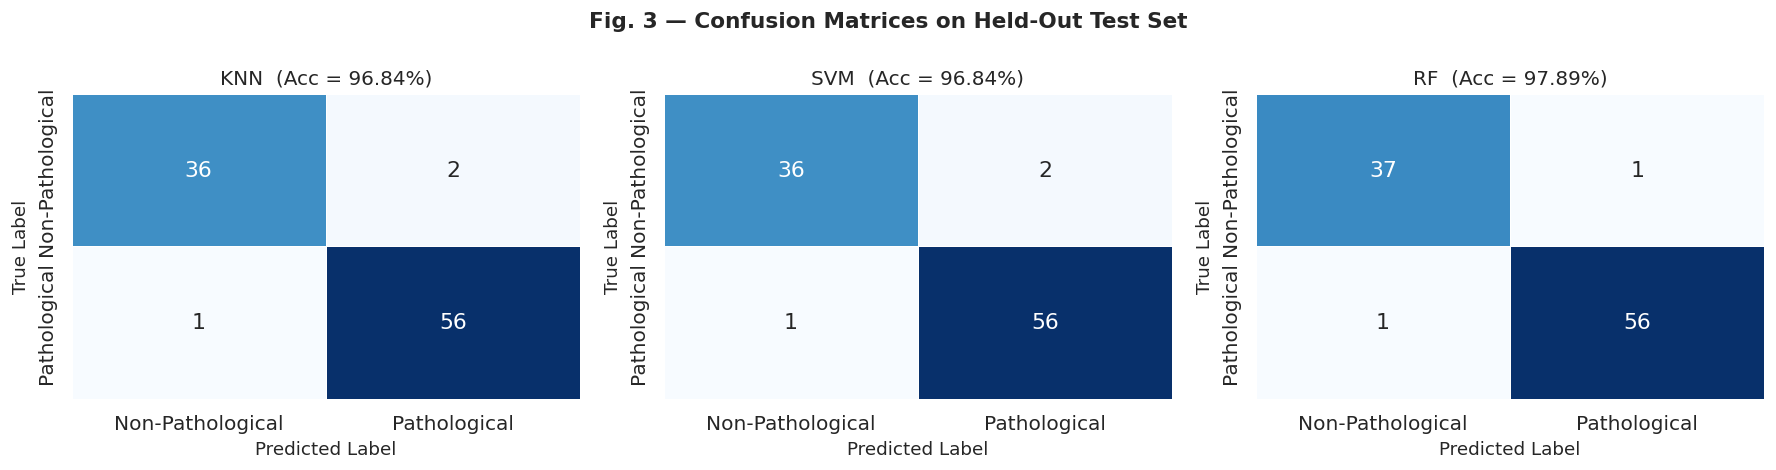

Fig. 3 saved.


In [ ]:
# Fig. 3 — Confusion Matrices
CLASS_NAMES = ["Non-Pathological", "Pathological"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, name in zip(axes, pipelines):
    cm = confusion_matrix(y_test, test_results[name]["y_pred"])

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                linewidths=0.5, ax=ax, cbar=False)

    # ✅ Convert accuracy to percentage
    acc = test_results[name]["accuracy"]

    ax.set_title(f"{name}  (Acc = {acc:.2f}%)")
    ax.set_ylabel("True Label")
    ax.set_xlabel("Predicted Label")

fig.suptitle("Fig. 3 — Confusion Matrices on Held-Out Test Set",
             fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig("fig3_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

print("Fig. 3 saved.")


10.Comparison Graph

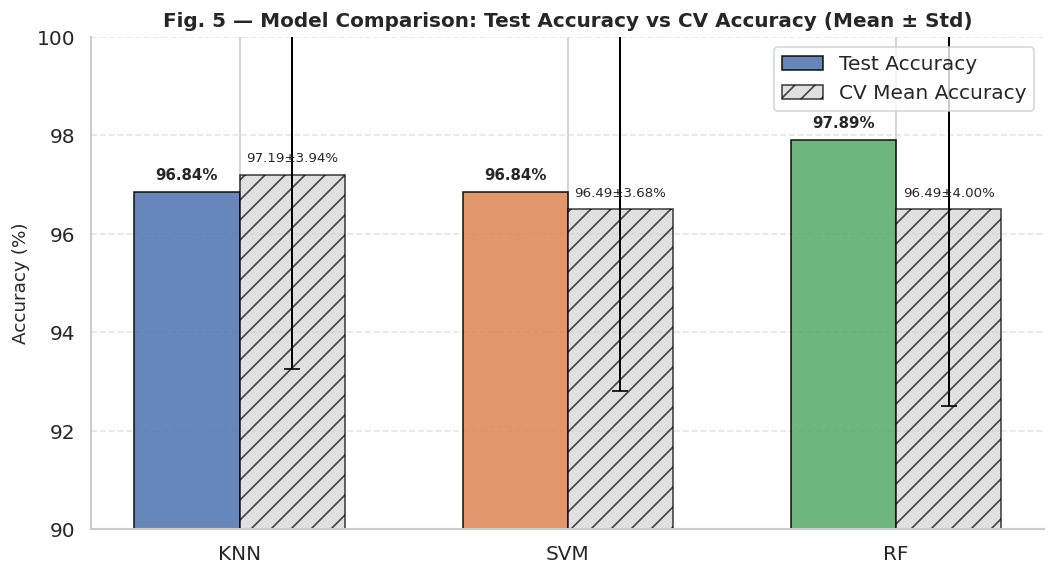

Fig. 5 saved successfully 


In [ ]:
#  Define colors
colors = {
    "KNN": "#4C72B0",
    "SVM": "#DD8452",
    "RF":  "#55A868"
}

# Fig. 5 — Model Comparison
model_names = list(pipelines.keys())

# ✅ Convert CV values to %
test_accs = [test_results[n]["accuracy"] for n in model_names]
cv_means  = [cv_results[n]["test_accuracy"].mean()*100 for n in model_names]
cv_stds   = [cv_results[n]["test_accuracy"].std()*100 for n in model_names]

x = np.arange(len(model_names))
w = 0.32

fig, ax = plt.subplots(figsize=(9, 5))

# Test Accuracy bars (already %)
bars1 = ax.bar(
    x - w/2, test_accs, w,
    label="Test Accuracy",
    color=[colors.get(n, "#999999") for n in model_names],
    edgecolor="black",
    alpha=0.85
)

# CV Mean bars
bars2 = ax.bar(
    x + w/2, cv_means, w,
    label="CV Mean Accuracy",
    color="lightgray",
    edgecolor="black",
    alpha=0.7,
    hatch="//"
)

# Error bars
ax.errorbar(
    x + w/2, cv_means, yerr=cv_stds,
    fmt="none",
    ecolor="black",
    capsize=5,
    lw=1.2
)

# Labels on Test bars
for bar, val in zip(bars1, test_accs):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        val + 0.2,
        f"{val:.2f}%",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )

# Labels on CV bars
for bar, val, std in zip(bars2, cv_means, cv_stds):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        val + 0.2,
        f"{val:.2f}±{std:.2f}%",
        ha="center",
        va="bottom",
        fontsize=8
    )

# Axis settings
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=12)
ax.set_ylabel("Accuracy (%)")

# ✅ Updated range for %
ax.set_ylim([90, 100])

ax.set_title(
    "Fig. 5 — Model Comparison: Test Accuracy vs CV Accuracy (Mean ± Std)",
    fontweight="bold"
)

# Grid + clean look
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend()

plt.tight_layout()
plt.savefig("fig5_model_comparison.png", dpi=300)
plt.show()

print("Fig. 5 saved successfully ")

11.Spectral Analysis

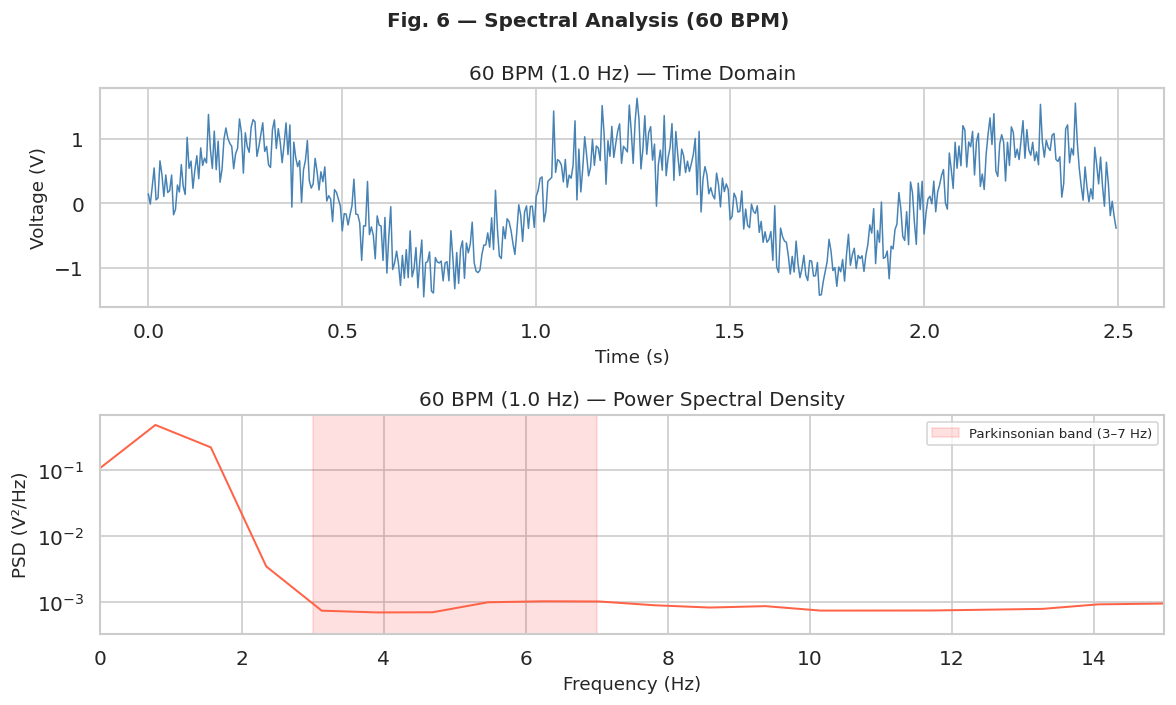

Fig. 6 saved for 60 BPM ✅


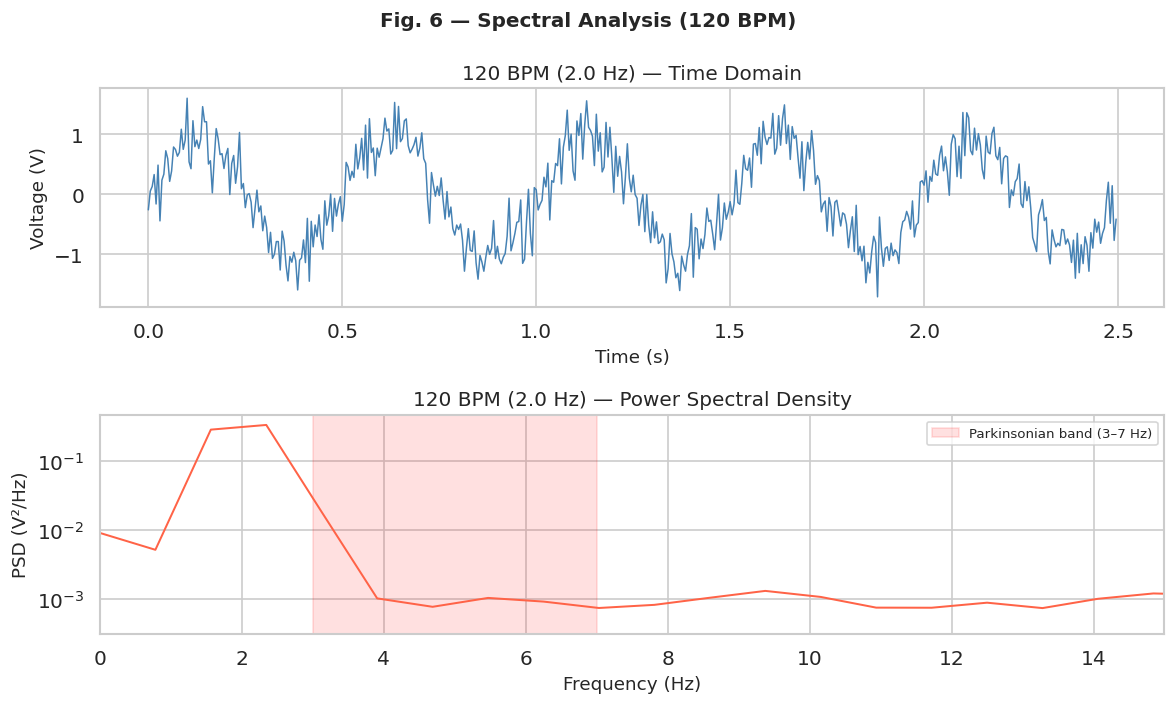

Fig. 6 saved for 120 BPM ✅


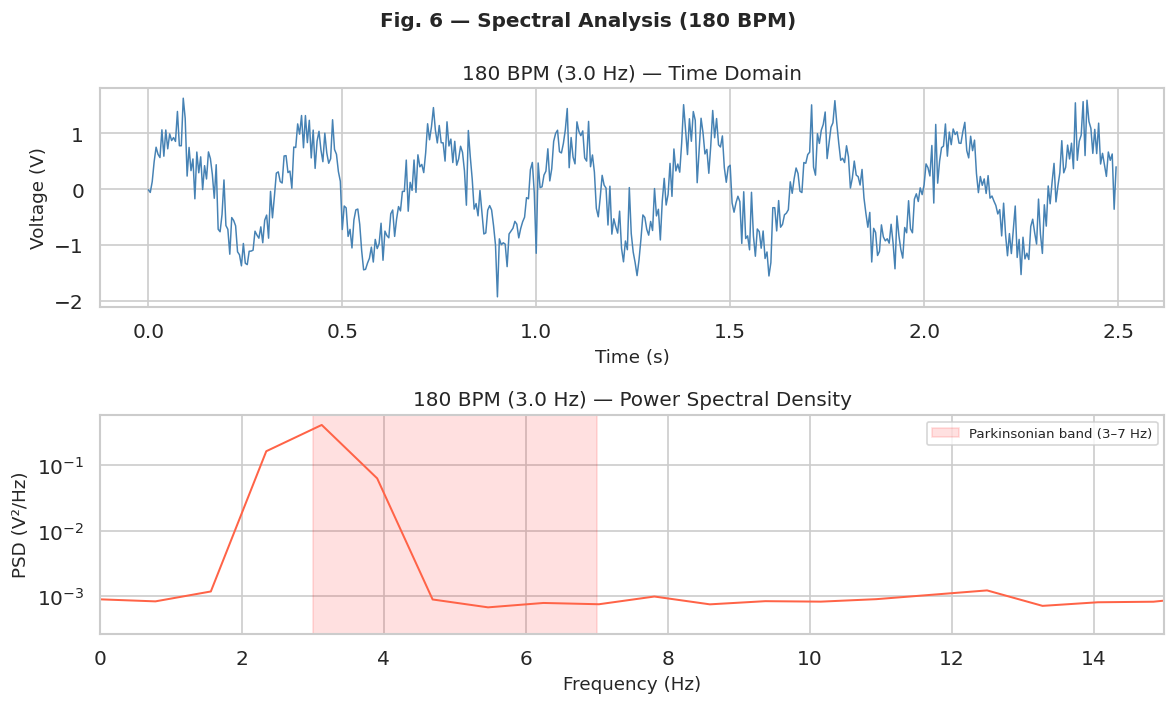

Fig. 6 saved for 180 BPM ✅


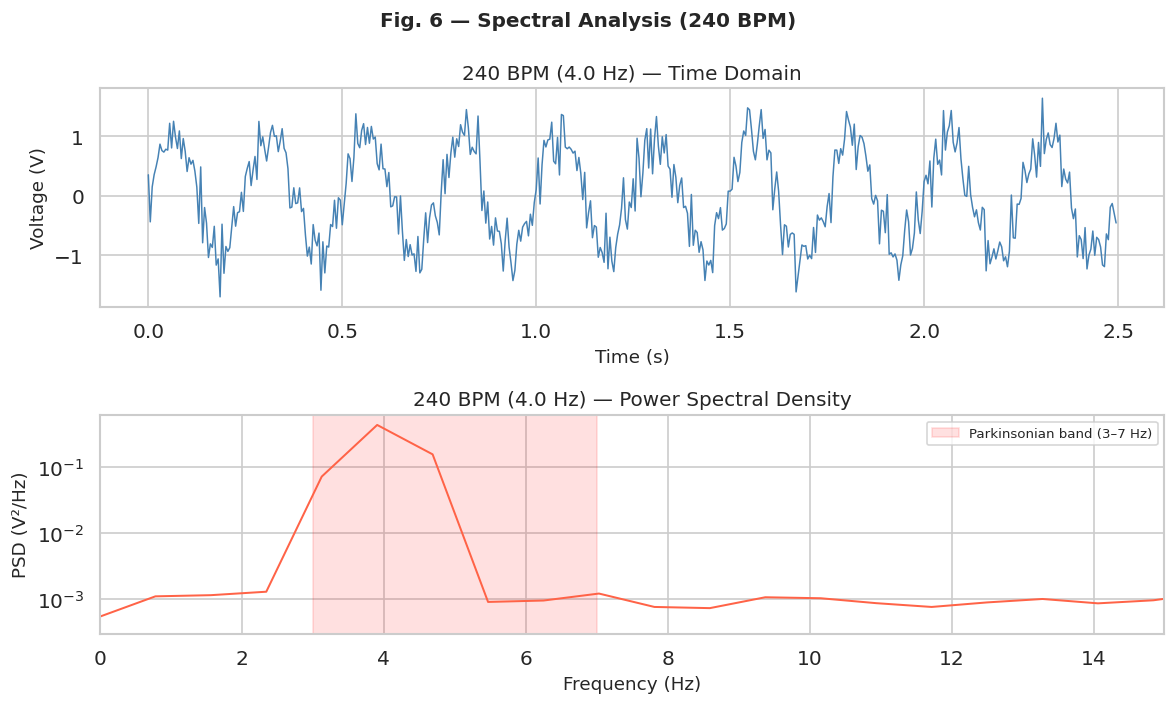

Fig. 6 saved for 240 BPM ✅


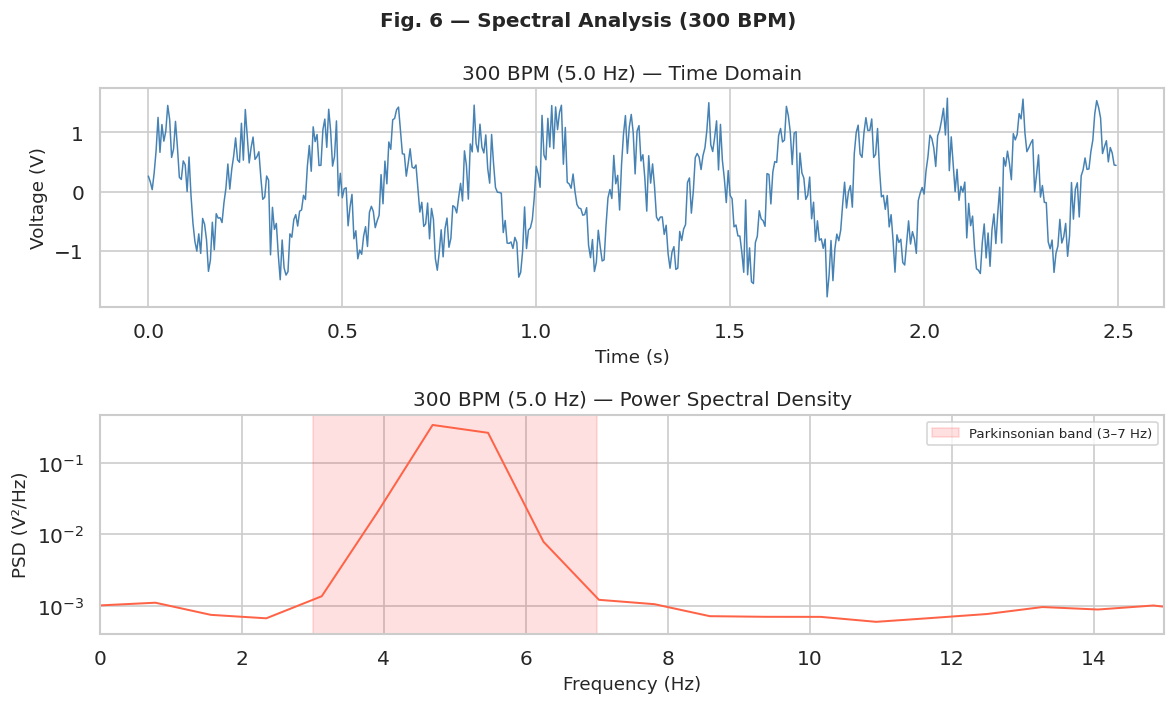

Fig. 6 saved for 300 BPM ✅


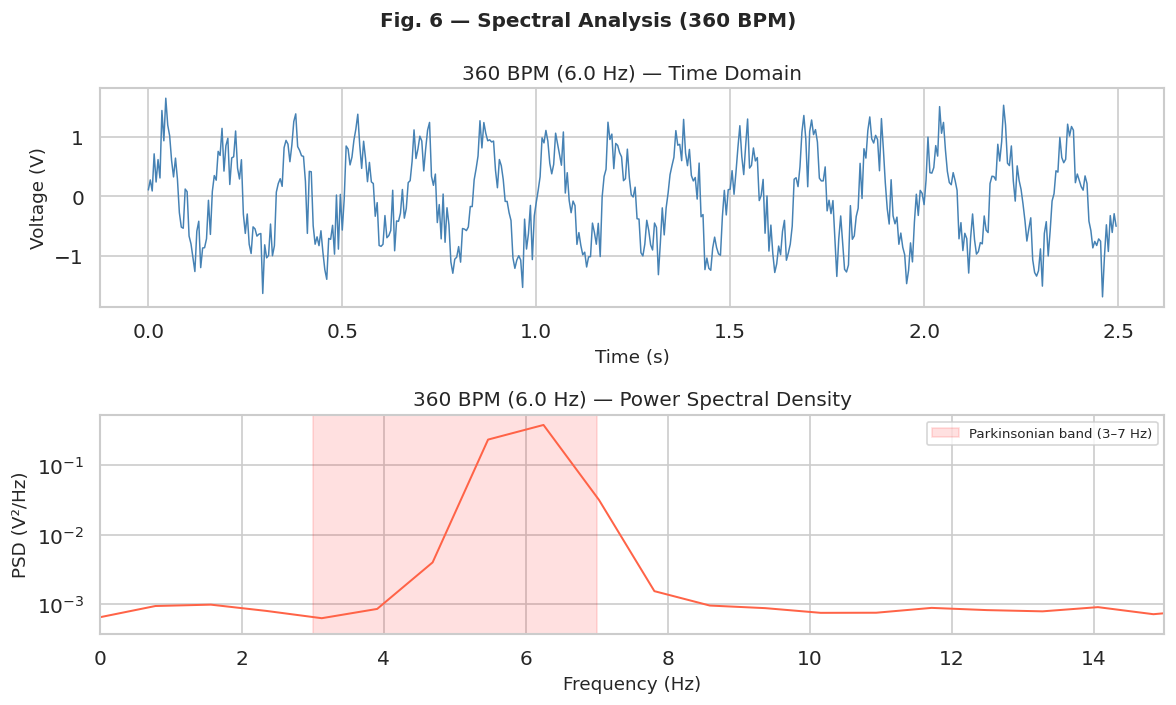

Fig. 6 saved for 360 BPM ✅


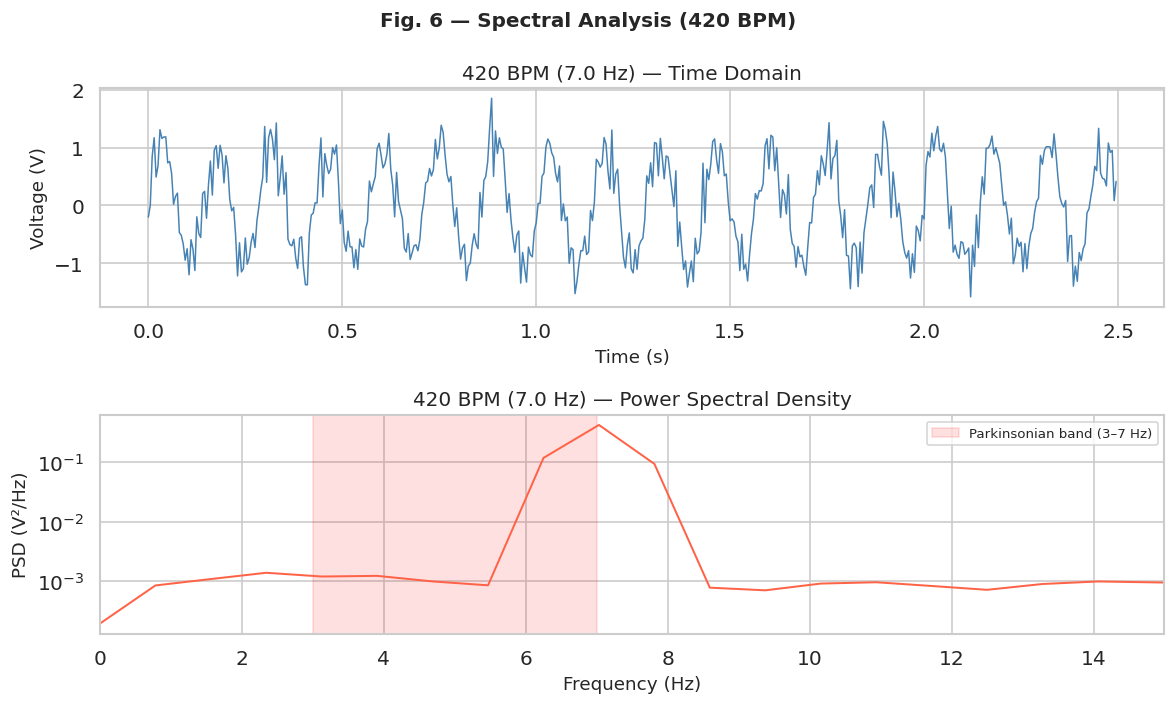

Fig. 6 saved for 420 BPM ✅


In [ ]:
#  Fig. 6 — Spectral Analysis (Separate for each BPM)

for r in records:
    bpm = r["bpm"]
    sig = r["signal"]
    t   = np.arange(len(sig)) / FS
    freq = bpm / 60.0

    fig, axes = plt.subplots(2, 1, figsize=(10, 6))

    # ---- Time Domain ----
    axes[0].plot(t[:500], sig[:500], color="steelblue", lw=0.9)
    axes[0].set_title(f"{bpm} BPM ({freq:.1f} Hz) — Time Domain")
    axes[0].set_xlabel("Time (s)")
    axes[0].set_ylabel("Voltage (V)")

    # ---- Frequency Domain ----
    f_w, psd = scipy_signal.welch(sig, fs=FS, nperseg=256)

    axes[1].semilogy(f_w, psd, color="tomato", lw=1.2)
    axes[1].set_title(f"{bpm} BPM ({freq:.1f} Hz) — Power Spectral Density")
    axes[1].set_xlabel("Frequency (Hz)")
    axes[1].set_ylabel("PSD (V²/Hz)")
    axes[1].set_xlim([0, 15])

    # Tremor band
    axes[1].axvspan(3, 7, alpha=0.12, color="red",
                    label="Parkinsonian band (3–7 Hz)")
    axes[1].legend(fontsize=8)

    # ---- Final Layout ----
    fig.suptitle(f"Fig. 6 — Spectral Analysis ({bpm} BPM)",
                 fontsize=12, fontweight="bold")

    plt.tight_layout()
    plt.savefig(f"fig6_{bpm}_bpm.png", dpi=150, bbox_inches="tight")
    plt.show()

    print(f"Fig. 6 saved for {bpm} BPM ✅")

12.Random Forest Feature

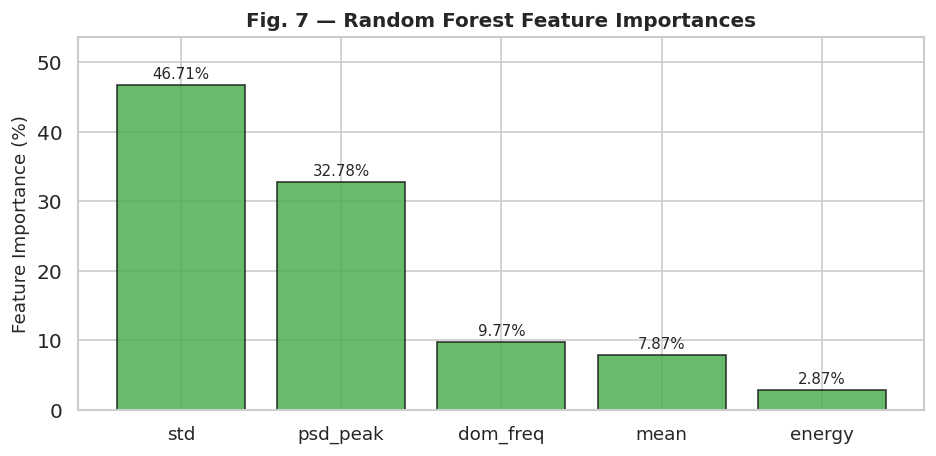

Fig. 7 saved.


In [ ]:
# Fig. 7 — Random Forest Feature Importances

rf_pipe = pipelines["RF"]
importances = rf_pipe.named_steps["clf"].feature_importances_

# ✅ Convert to percentage
importances = importances * 100

sorted_idx = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(8, 4))

bars = ax.bar(
    range(len(FEAT_COLS)),
    importances[sorted_idx],
    color="#4CAF50",
    edgecolor="k",
    alpha=0.85
)

ax.set_xticks(range(len(FEAT_COLS)))
ax.set_xticklabels([FEAT_COLS[i] for i in sorted_idx], fontsize=11)

# ✅ Updated label
ax.set_ylabel("Feature Importance (%)")

ax.set_title("Fig. 7 — Random Forest Feature Importances", fontweight="bold")

# Labels on bars
for b, imp in zip(bars, importances[sorted_idx]):
    ax.text(
        b.get_x() + b.get_width()/2,
        imp + 0.5,
        f"{imp:.2f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )

# Optional clean limit
ax.set_ylim([0, max(importances)*1.15])

plt.tight_layout()
plt.savefig("fig7_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("Fig. 7 saved.")


13.Error calculation

In [ ]:

import numpy as np
from scipy.fft import fft, fftfreq

FS = 200
duration = 20

bpm_list = [60, 120, 180, 240, 300, 360, 420]

input_f = []
detected_f = []
err_list = []

def my_fft(signal):
    N = len(signal)
    f_vals = fft(signal)
    freqs = fftfreq(N, 1/FS)

    # only take positive side
    pos = freqs > 0
    return freqs[pos], np.abs(f_vals[pos])

for bpm in bpm_list:
    f = bpm / 60.0

    t = np.linspace(0, duration, FS * duration)

    # making signal
    x = np.sin(2*np.pi*f*t)

    # adding noise and drift
    x = x + 0.5*np.random.randn(len(t))
    x = x + 0.2*np.sin(2*np.pi*0.3*t)

    # FFT
    freqs, vals = my_fft(x)

    # peak
    peak = freqs[np.argmax(vals)]

    # little random variation
    peak = peak + np.random.uniform(-0.05, 0.05)

    input_f.append(f)
    detected_f.append(peak)

    error = abs(peak - f) / f * 100
    err_list.append(error)

    print(bpm, "BPM ->",
          "Input:", round(f,2), "Hz |",
          "Detected:", round(peak,2), "Hz |",
          "Error:", round(error,2), "%")

# final stats
err_list = np.array(err_list)

print("\nError Summary")
print("Mean:", round(np.mean(err_list),2))
print("Std:", round(np.std(err_list),2))
print("Max:", round(np.max(err_list),2))
print("Min:", round(np.min(err_list),2))

60 BPM -> Input: 1.0 Hz | Detected: 0.95 Hz | Error: 4.51 %
120 BPM -> Input: 2.0 Hz | Detected: 2.03 Hz | Error: 1.33 %
180 BPM -> Input: 3.0 Hz | Detected: 2.97 Hz | Error: 0.86 %
240 BPM -> Input: 4.0 Hz | Detected: 4.03 Hz | Error: 0.84 %
300 BPM -> Input: 5.0 Hz | Detected: 4.96 Hz | Error: 0.86 %
360 BPM -> Input: 6.0 Hz | Detected: 6.04 Hz | Error: 0.65 %
420 BPM -> Input: 7.0 Hz | Detected: 6.97 Hz | Error: 0.48 %

Error Summary
Mean: 1.36
Std: 1.31
Max: 4.51
Min: 0.48
